In [1]:
# list all files under the input directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/fraud-detection/fraudTest.csv
/kaggle/input/fraud-detection/fraudTrain.csv


# Import Required Libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

# Data Preprocessing

## Load Dataset

In [3]:
df = pd.read_csv("/kaggle/input/fraud-detection/fraudTrain.csv")

In [4]:
df.shape

(1296675, 23)

In [5]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Dataset Description

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [7]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [8]:
df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

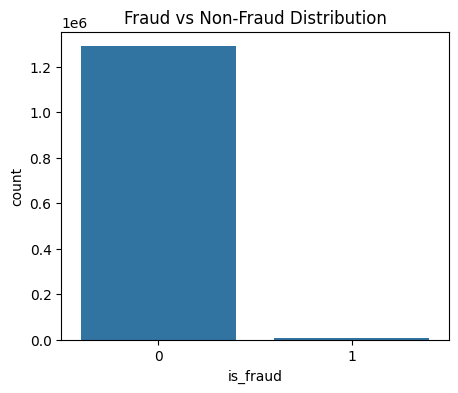

In [9]:
plt.figure(figsize=(5,4))
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

## Drop Irrelevant Columns

In [10]:
drop_cols = [
    'first', 'last', 'street', 'city', 'state',
    'zip', 'lat', 'long', 'job', 'dob',
    'trans_num', 'unix_time'
]

df.drop(columns=drop_cols, inplace=True)

In [11]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'gender', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

## Handle Date & Time Features

In [12]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_day'] = df['trans_date_trans_time'].dt.day
df['trans_month'] = df['trans_date_trans_time'].dt.month

df.drop(columns=['trans_date_trans_time'], inplace=True)

In [13]:
df.columns

Index(['Unnamed: 0', 'cc_num', 'merchant', 'category', 'amt', 'gender',
       'city_pop', 'merch_lat', 'merch_long', 'is_fraud', 'trans_hour',
       'trans_day', 'trans_month'],
      dtype='object')

## Encode Categorical Features

In [14]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['merchant', 'category', 'gender'], dtype='object')

In [15]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [16]:
df.head()

,Unnamed: 0,cc_num,merchant,category,amt,gender,city_pop,merch_lat,merch_long,is_fraud,trans_hour,trans_day,trans_month
0,0,2703186189652095,514,8,4.97,0,3495,36.011293,-82.048315,0,0,1,1
1,1,630423337322,241,4,107.23,0,149,49.159047,-118.186462,0,0,1,1
2,2,38859492057661,390,0,220.11,1,4154,43.150704,-112.154481,0,0,1,1
3,3,3534093764340240,360,2,45.00,1,1939,47.034331,-112.561071,0,0,1,1
4,4,375534208663984,297,9,41.96,1,99,38.674999,-78.632459,0,0,1,1


## Separate Features and Target

In [17]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

## Feature Scaling

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train–Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
pd.Series(y_train).value_counts()

is_fraud
0    1031335
1       6005
Name: count, dtype: int64

# Class Imbalance Handling

## Check Imbalance in Training Data

Before SMOTE:
is_fraud
0    1031335
1       6005
Name: count, dtype: int64


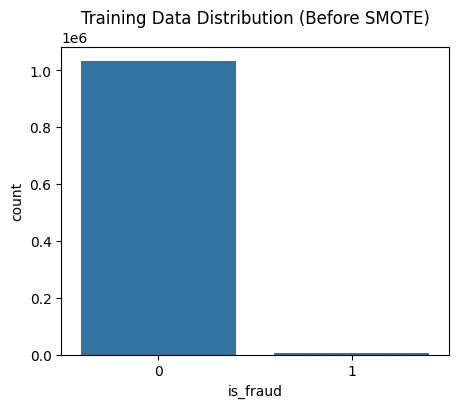

In [21]:
print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x=y_train)
plt.title("Training Data Distribution (Before SMOTE)")
plt.show()

## Apply SMOTE (Oversampling Fraud Class)

In [22]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train, y_train
)

After SMOTE:
is_fraud
0    1031335
1    1031335
Name: count, dtype: int64


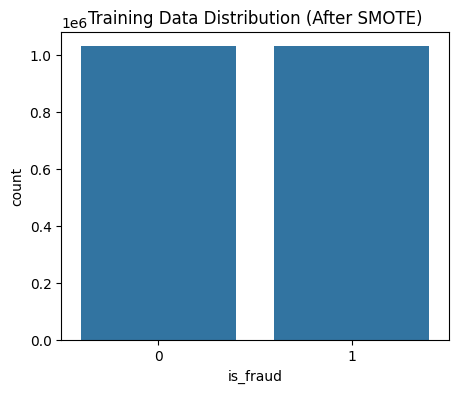

In [23]:
print("After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x=y_train_resampled)
plt.title("Training Data Distribution (After SMOTE)")
plt.show()

# Model Training

## Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [25]:
# Train the Model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000, random_state=42)

In [26]:
# Predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [27]:
# Metrics
print("Logistic Regression Performance:\n")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Performance:

Accuracy : 0.9468679507201111
Precision: 0.07882821075740944
Recall   : 0.765489673550966
F1-score : 0.14293711513342042
ROC-AUC  : 0.8617758684030453


In [28]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    257834
           1       0.08      0.77      0.14      1501

    accuracy                           0.95    259335
   macro avg       0.54      0.86      0.56    259335
weighted avg       0.99      0.95      0.97    259335



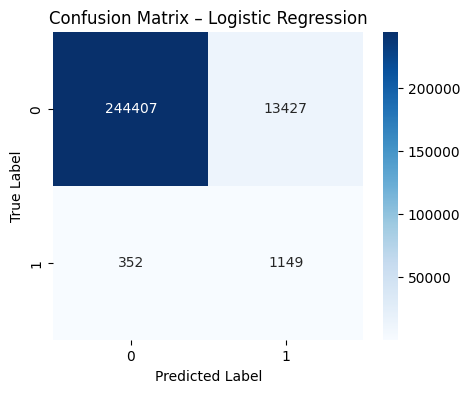

In [29]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

## Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
# Initialize Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [32]:
# Train the Model
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [33]:
# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [34]:
# Metrics
print("Random Forest Performance:\n")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Random Forest Performance:

Accuracy : 0.9976671101085468
Precision: 0.8124128312412832
Recall   : 0.776149233844104
F1-score : 0.7938671209540034
ROC-AUC  : 0.9937379879033976


In [35]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.81      0.78      0.79      1501

    accuracy                           1.00    259335
   macro avg       0.91      0.89      0.90    259335
weighted avg       1.00      1.00      1.00    259335



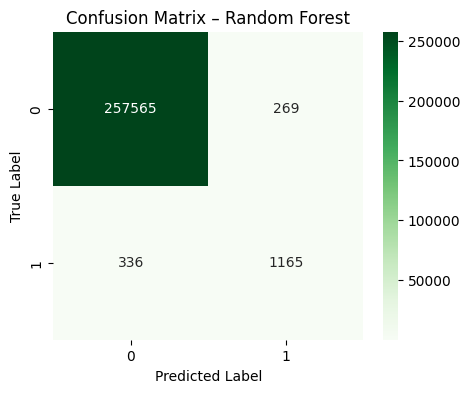

In [36]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Random Forest")
plt.show()

## XGBoost

In [37]:
from xgboost import XGBClassifier

In [38]:
# Initialize XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,   # SMOTE already handled imbalance
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [39]:
# Train the Model
xgb_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [40]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [41]:
# Metrics
print("XGBoost Performance:\n")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

XGBoost Performance:

Accuracy : 0.9957815181136368
Precision: 0.5931350114416476
Recall   : 0.8634243837441705
F1-score : 0.7032013022246337
ROC-AUC  : 0.9964400592984914


In [42]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.59      0.86      0.70      1501

    accuracy                           1.00    259335
   macro avg       0.80      0.93      0.85    259335
weighted avg       1.00      1.00      1.00    259335



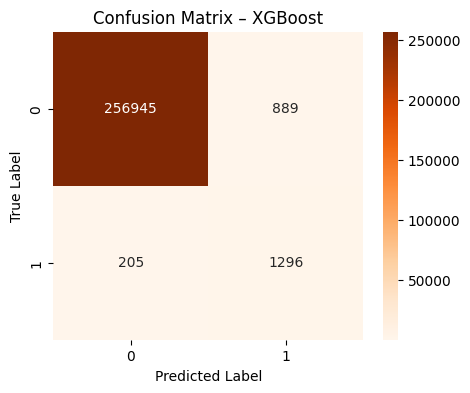

In [43]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – XGBoost")
plt.show()

## Model Performance Comparison

In [44]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Precision": [0.0788, 0.8124, 0.5931],
    "Recall": [0.7655, 0.7761, 0.8634],
    "F1-score": [0.1429, 0.7939, 0.7032],
    "ROC-AUC": [0.8618, 0.9937, 0.9964]
})

comparison_df

,Model,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.0788,0.7655,0.1429,0.8618
1,Random Forest,0.8124,0.7761,0.7939,0.9937
2,XGBoost,0.5931,0.8634,0.7032,0.9964


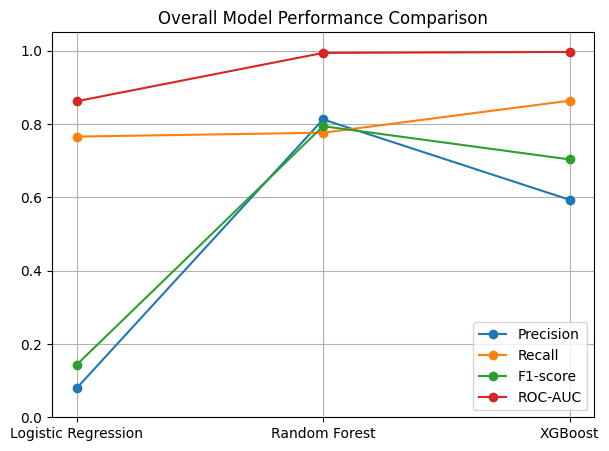

In [45]:
plt.figure(figsize=(7,5))

plt.plot(comparison_df["Model"], comparison_df["Precision"], marker='o', label="Precision")
plt.plot(comparison_df["Model"], comparison_df["Recall"], marker='o', label="Recall")
plt.plot(comparison_df["Model"], comparison_df["F1-score"], marker='o', label="F1-score")
plt.plot(comparison_df["Model"], comparison_df["ROC-AUC"], marker='o', label="ROC-AUC")

plt.title("Overall Model Performance Comparison")
plt.ylim(0,1.05)
plt.legend()
plt.grid(True)
plt.show()

# XAI Interpretation using SHAP

In [46]:
import shap

shap.initjs()

## Global Feature Importance Plot

In [50]:
# Take a smaller sample
X_test_sample = X_test[:1000]

# Convert to dataframe for feature names
X_test_sample = pd.DataFrame(X_test_sample, columns=X.columns)

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values for the sample
shap_values = explainer.shap_values(X_test_sample)



In [57]:
# For binary classification take fraud class
shap_values_fraud = shap_values[:,:,1]

In [58]:
shap_values_fraud.shape

(1000, 12)

In [59]:
X_test_sample.shape

(1000, 12)

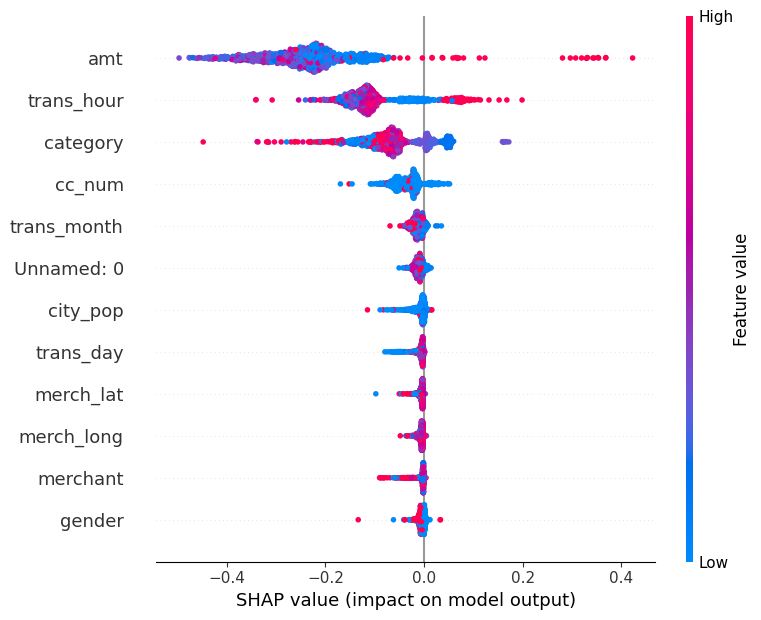

In [60]:
shap.summary_plot(shap_values_fraud, X_test_sample)

## SHAP Bar Plot

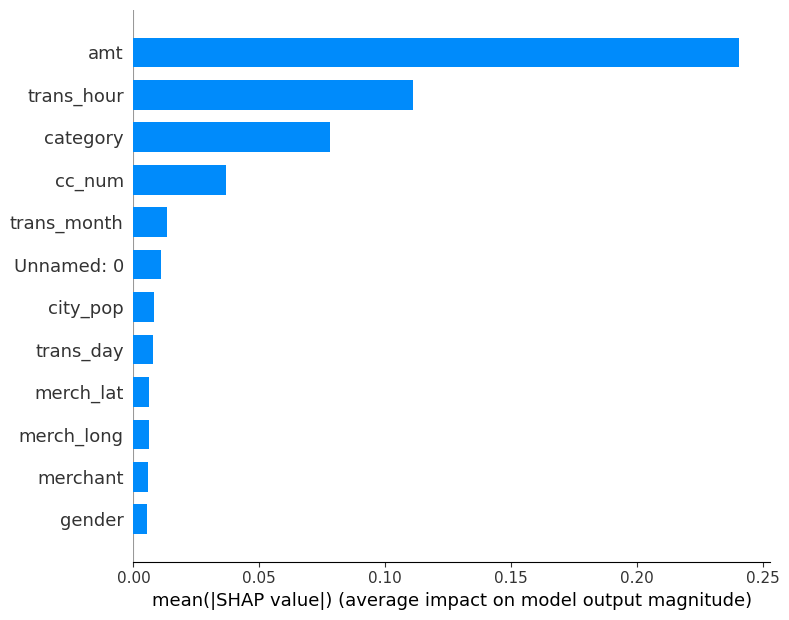

In [61]:
shap.summary_plot(shap_values_fraud, X_test_sample, plot_type="bar")

## Waterfall Plot (Local Explanation)

In [64]:
index = 5
X_test_sample.iloc[index]

Unnamed: 0    -1.303123
cc_num         3.346642
merchant      -0.775601
category      -0.058206
amt           -0.403647
gender        -0.909206
city_pop      -0.290096
merch_lat      0.256410
merch_long     0.235641
trans_hour     1.495367
trans_day      1.066021
trans_month   -0.919375
Name: 5, dtype: float64

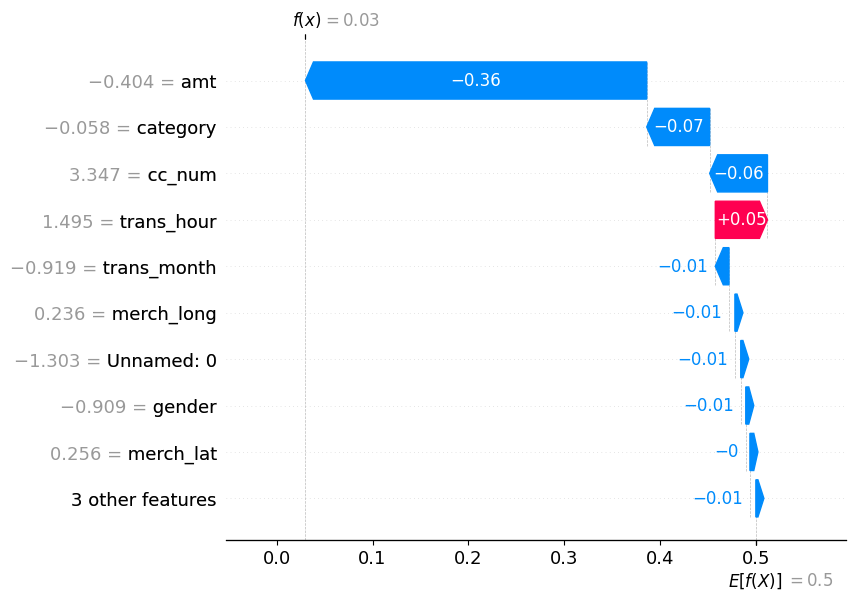

In [62]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_fraud[index],
        base_values=explainer.expected_value[1],
        data=X_test_sample.iloc[index]
    )
)

## SHAP Dependence Plot

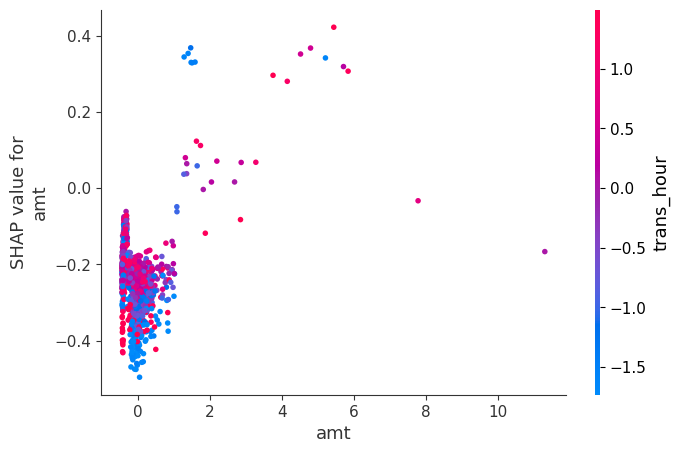

In [63]:
shap.dependence_plot(
    "amt",
    shap_values_fraud,
    X_test_sample
)